# Exploratory Data Analysis 

This project predicts whether a credit card transcation is fraudulent using masked transaction features that differ between legitimate and fradualent transactions. Our target is the Class. Where Class = 1 results in fraud and Class = 0 results in legitimate. 

This (eda) notebook explores the credit card fraud data set. Given that less than 1% of the transactions in the dataset account for fraudulent transactions it is crucial to understand the data distribution, data types, and features. 

### 1. Import and Inspect the Data 

In [12]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import sys, os 

df = pd.read_csv("data/creditcard.csv")
rows, cols = df.shape
print(f"Dataset Loaded: Rows: {rows}, Columns: {cols}")
df.head()

Dataset Loaded: Rows: 50492, Columns: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,66706.0,1.199490,0.197301,0.616923,0.554820,-0.526523,-0.785182,-0.036202,-0.070460,-0.224568,...,-0.191542,-0.597586,0.148051,0.529668,0.158453,0.064369,-0.033132,0.011166,3.59,0
1,118737.0,2.054939,-0.005134,-1.050691,0.401563,-0.047484,-1.112092,0.218426,-0.350042,0.430742,...,-0.275390,-0.616070,0.338719,0.006520,-0.288834,0.198696,-0.062744,-0.059034,1.29,0
2,67555.0,-0.943726,-0.366261,2.292128,-1.909816,-0.305247,1.903637,-0.998268,0.757791,0.170689,...,0.109482,0.651761,-0.502554,-1.659885,0.669679,-0.000532,0.228359,0.088451,2.00,0
3,6428.0,-0.960946,0.864361,1.286077,0.131434,0.630708,-0.746227,0.567456,-0.281288,0.965197,...,-0.375636,-0.589018,0.275299,-0.161066,-0.491036,-0.020583,0.150700,0.179427,5.36,0
4,159884.0,1.688499,0.142083,-2.975027,0.857739,0.752403,-1.699499,0.883376,-0.527584,-0.050348,...,0.021742,-0.179006,-0.069067,0.967166,0.029453,0.613583,-0.095408,0.044466,195.00,0


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50492 entries, 0 to 50491
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    50492 non-null  float64
 1   V1      50492 non-null  float64
 2   V2      50492 non-null  float64
 3   V3      50492 non-null  float64
 4   V4      50492 non-null  float64
 5   V5      50492 non-null  float64
 6   V6      50492 non-null  float64
 7   V7      50492 non-null  float64
 8   V8      50492 non-null  float64
 9   V9      50492 non-null  float64
 10  V10     50492 non-null  float64
 11  V11     50492 non-null  float64
 12  V12     50492 non-null  float64
 13  V13     50492 non-null  float64
 14  V14     50492 non-null  float64
 15  V15     50492 non-null  float64
 16  V16     50492 non-null  float64
 17  V17     50492 non-null  float64
 18  V18     50492 non-null  float64
 19  V19     50492 non-null  float64
 20  V20     50492 non-null  float64
 21  V21     50492 non-null  float64
 22  V22     5

In [14]:
df.describe().round(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,50492.000,50492.000,50492.000,50492.000,50492.000,50492.000,50492.000,50492.000,50492.000,50492.000,...,50492.000,50492.000,50492.000,50492.000,50492.000,50492.000,50492.000,50492.000,50492.000,50492.000
mean,94841.311,-0.036,0.025,-0.057,0.044,-0.013,-0.012,-0.052,0.009,-0.011,...,0.002,-0.000,0.000,-0.001,-0.003,0.002,0.003,0.001,87.205,0.010
std,47493.217,2.085,1.721,1.739,1.487,1.452,1.334,1.433,1.329,1.144,...,0.797,0.734,0.643,0.607,0.523,0.484,0.414,0.306,227.164,0.098
min,0.000,-46.855,-48.061,-31.104,-5.520,-28.816,-20.870,-43.557,-50.420,-13.434,...,-22.889,-8.887,-30.270,-2.837,-6.429,-1.727,-9.544,-8.308,0.000,0.000
25%,54334.750,-0.929,-0.597,-0.922,-0.826,-0.699,-0.775,-0.568,-0.205,-0.648,...,-0.228,-0.551,-0.162,-0.356,-0.319,-0.328,-0.070,-0.052,5.660,0.000
50%,84737.500,0.015,0.076,0.167,-0.003,-0.056,-0.279,0.036,0.025,-0.050,...,-0.026,0.007,-0.010,0.041,0.015,-0.047,0.002,0.012,21.990,0.000
75%,139325.750,1.312,0.819,1.016,0.770,0.622,0.394,0.570,0.331,0.598,...,0.188,0.526,0.149,0.438,0.346,0.245,0.095,0.080,76.805,0.000
max,172787.000,2.420,22.058,4.102,13.129,29.162,21.190,26.250,20.007,10.371,...,27.203,8.362,17.752,4.016,5.852,3.517,9.880,15.870,8360.000,1.000


In [15]:
print(f"Duplicated Rows:  {df.duplicated().sum()}")
print(f"Missing Values : {df.isnull().sum().sum()}")
print("Class Value Counts: ")
print(df["Class"].value_counts())
print(f"\nFraud Rate     : {df["Class"].mean()*100:.2f}%")


Duplicated Rows:  53
Missing Values : 0
Class Value Counts: 
Class
0    50000
1      492
Name: count, dtype: int64

Fraud Rate     : 0.97%


### Class Distribution 
The dataset is highly imbalanced. A model hat predicts every transaction as legitimate would achieve a 99% accuracy but it would detect 0% fraud cases. Therefore, ccuracy is alone is not a useful metric. 

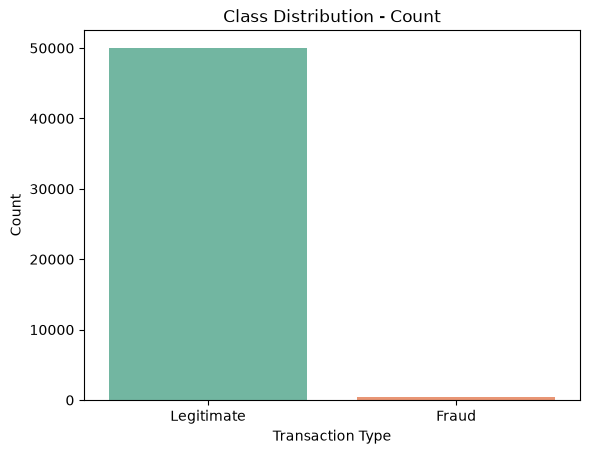

In [16]:
ax = sns.countplot(x = "Class", data = df, hue="Class", palette = "Set2", legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Legitimate", "Fraud"])
ax.set_title("Class Distribution - Count")
ax.set_xlabel("Transaction Type")
ax.set_ylabel("Count")

plt.show()



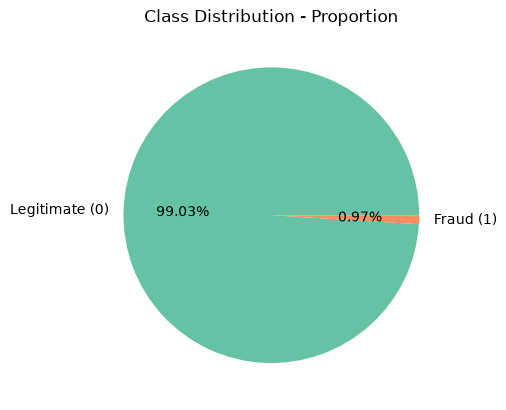

In [17]:
labels = ["Legitimate (0)","Fraud (1)"]
class_counts = df["Class"].value_counts()
colors = sns.color_palette("Set2")

plt.pie(class_counts, labels=labels, colors=colors, autopct="%.2f%%")
plt.title("Class Distribution - Proportion")

plt.show()


### Amount Distribution

Fraud has a lower median but a higher mean, meaning many fruad cases are small but some are larger, pulling the average upward. After further analyzation we can conclude that the Amount alone cannot seperate the transactions from being fraud or legitimate. 

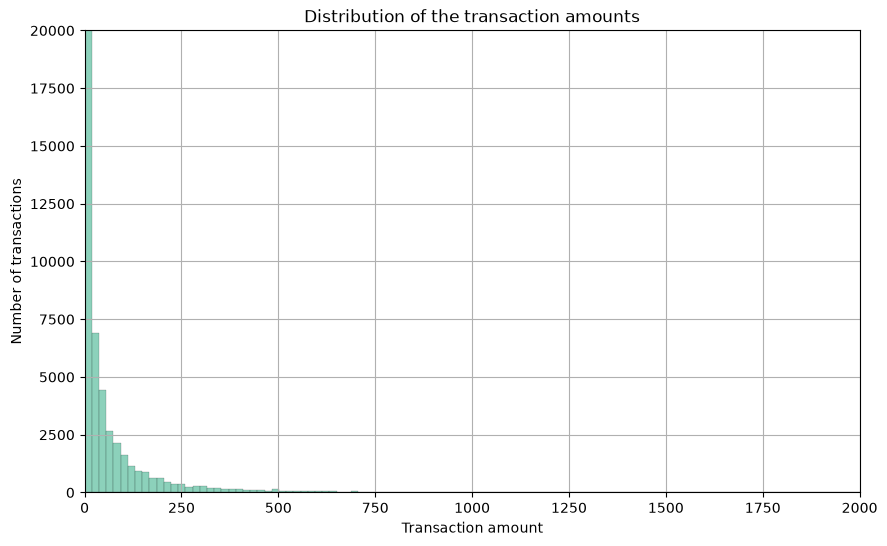

In [18]:
plt.figure(figsize=(10, 6))
ax = sns.histplot(data=df, x = "Amount", color=sns.color_palette("Set2")[0])
plt.title("Distribution of the transaction amounts")
plt.ylabel("Number of transactions")
plt.xlabel("Transaction amount")
plt.grid(True)
ax.set_xlim(0,2000)
ax.set_ylim(0,20000)
plt.show()

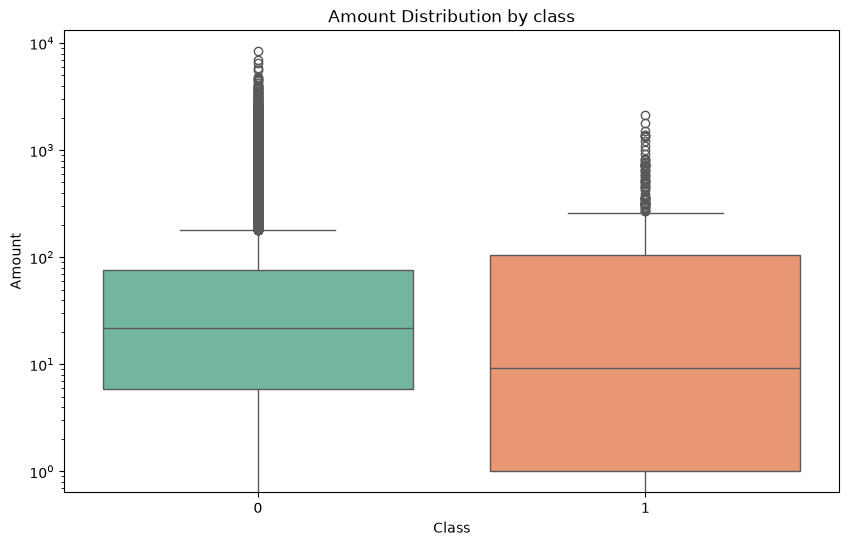

In [19]:
plt.figure(figsize=(10,6))
ax = sns.boxplot(x = "Class", y = "Amount", data=df, hue="Class", palette="Set2", legend=False)
ax.set_yscale("log")
ax.set_title("Amount Distribution by class")
plt.show()

In [20]:
print("Summary Stats for amount")
legit = df[df["Class"] == 0]
fraud = df[df["Class"] == 1]
print("Legitimate: ")
print(f"Median: €{legit["Amount"].median():.2f}, mean: €{legit["Amount"].mean():.2f}, Count: {legit["Amount"].count()}, Max: €{legit["Amount"].max():.2f}, Min: €{legit["Amount"].min():.2f}, Standard Deviation: €{legit["Amount"].std():.2f}")
print("\nFraudulent: ")
print(f"Median: €{fraud["Amount"].median():.2f}, mean: €{fraud["Amount"].mean():.2f}, Count: {fraud["Amount"].count()}, Max: €{fraud["Amount"].max():.2f}, Min: €{fraud["Amount"].min():.2f}, Standard Deviation: €{fraud["Amount"].std():.2f}")

Summary Stats for amount
Legitimate: 
Median: €22.00, mean: €86.86, Count: 50000, Max: €8360.00, Min: €0.00, Standard Deviation: €226.83

Fraudulent: 
Median: €9.25, mean: €122.21, Count: 492, Max: €2125.87, Min: €0.00, Standard Deviation: €256.68


### Time Distribution 

This dataset covers the hours from 0 to 48. The legitimate transactions are consentrated from hours 8 to 25 and from 33 to 48 with transactions being over 1000. The fraudulent transactions are more spead out and seem to cluster more, having higher spikes in transaction amounts at one specific hour. Time does seem to be a useful variable as the fraudulent spikes are disctinct and could help link a transaction to being fraudulent. 

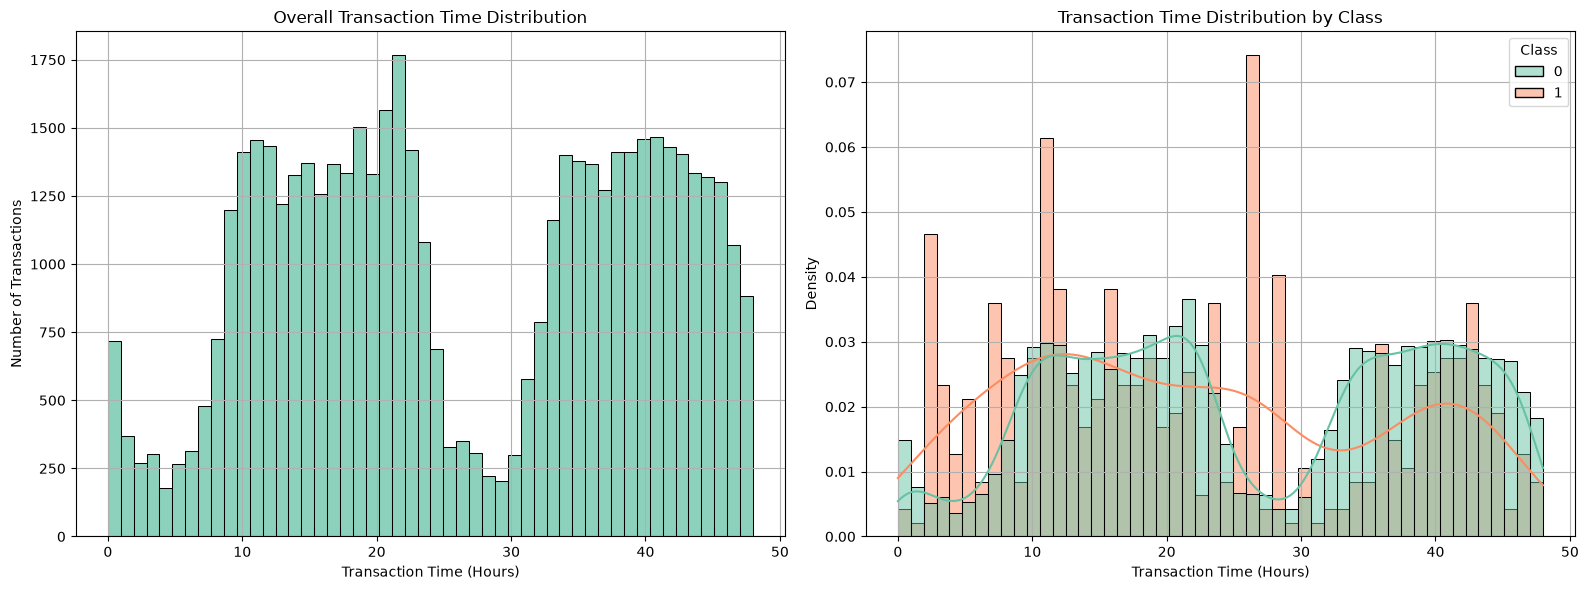

In [21]:
fig, axes = plt.subplots(1,2, figsize=(16,6))
df["Time_Hours"] = df["Time"] / 3600

# Plot 1: Overall time distribution
sns.histplot(
    data=df, 
    x="Time_Hours", 
    bins=50, 
    color=sns.color_palette("Set2")[0],
    ax=axes[0]
)

axes[0].set_title("Overall Transaction Time Distribution")
axes[0].set_xlabel("Transaction Time (Hours)")
axes[0].set_ylabel("Number of Transactions")
axes[0].grid(True)

# Plot 2: Time Distribution by class
sns.histplot(
    data=df, 
    x="Time_Hours", 
    hue="Class", 
    bins=50, 
    stat="density", 
    common_norm=False, 
    kde=True, 
    palette="Set2", 
    ax=axes[1]
)

axes[1].set_title("Transaction Time Distribution by Class")
axes[1].set_xlabel("Transaction Time (Hours)")
axes[1].set_ylabel("Density")
axes[1].grid(True)

plt.tight_layout()
plt.show()